In [1]:
# Part 2: Data Preprocessing
# ==========================================
# Import Libraries
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# Visualization Libraries
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10,6)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
print("Imported successfully")

Imported successfully


In [2]:
# ==========================================
# Load Dataset
# ==========================================
df = pd.read_csv("used_cars.csv")
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
# Shape
print(df.shape)
# Information
df.info()
# # First 5 rows
# df.head()
# # Statistical Summary
df.describe(include="all").T

(4009, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,4009,57,Ford,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,4009,1898,M3 Base,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year,4009.0,NaN,NaN,NaN,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0
milage,4009,2818,"110,000 mi.",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,3839,7,Gasoline,3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,4009,1146,2.0L I4 16V GDI DOHC Turbo,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4009,62,A/T,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext_col,4009,319,Black,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_col,4009,156,Black,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident,3896,2,None reported,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ==========================================
# Missing Values
# ==========================================
missing = df.isnull().sum()
missing

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [5]:
# Fill missing values in categorical columns with the mode
df["fuel_type"] = df["fuel_type"].fillna(df["fuel_type"].mode()[0])
df["accident"] = df["accident"].fillna(df["accident"].mode()[0])
df["clean_title"] = df["clean_title"].fillna("No")

# Fill missing values in numerical columns with the median
numerical_columns = df.select_dtypes(exclude="object").columns

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

# Check remaining missing values
missing = df.isnull().sum()
print(missing)

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64


In [6]:
# ==========================================
# Duplicate Records
# ==========================================
print(df.duplicated().sum())

0


In [7]:
# ==========================================
# Convert Price
# ==========================================

df["price"] = (
    df["price"]
      .astype(str)
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
      .astype(float)
)

# ==========================================
# Convert Mileage
# ==========================================

df["milage"] = (
    df["milage"]
      .astype(str)
      .str.replace(",", "", regex=False)
      .str.replace(" mi.", "", regex=False)
      .astype(float)
)

print(df["price"])
print(df["milage"])

0        10300.0
1        38005.0
2        54598.0
3        15500.0
4        34999.0
          ...   
4004    349950.0
4005     53900.0
4006     90998.0
4007     62999.0
4008     40000.0
Name: price, Length: 4009, dtype: float64
0       51000.0
1       34742.0
2       22372.0
3       88900.0
4        9835.0
         ...   
4004      714.0
4005    10900.0
4006     2116.0
4007    33000.0
4008    43000.0
Name: milage, Length: 4009, dtype: float64


In [8]:
# ==========================================
# Label Encoding
# ==========================================
label_encoder = LabelEncoder()
categorical_columns = df.select_dtypes(include="object").columns
print(categorical_columns)
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

Index(['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col',
       'int_col', 'accident', 'clean_title'],
      dtype='object')


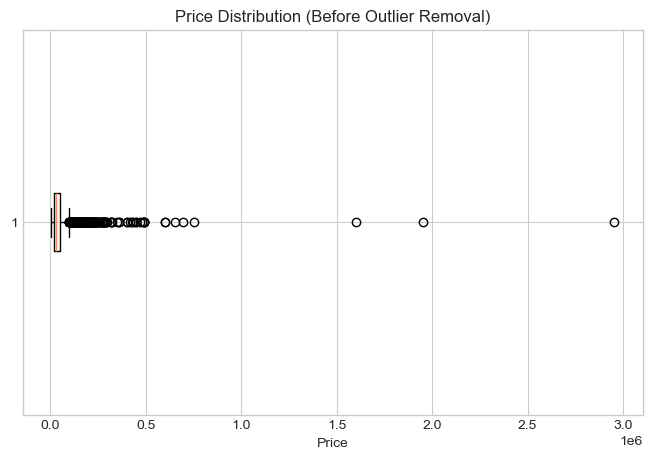

Q1: 17200.0
Q3: 49990.0
IQR: 32790.0
Lower Bound: -31985.0
Upper Bound: 99175.0
Number of outliers: 244
Original shape : (4009, 12)
Cleaned shape  : (3765, 12)


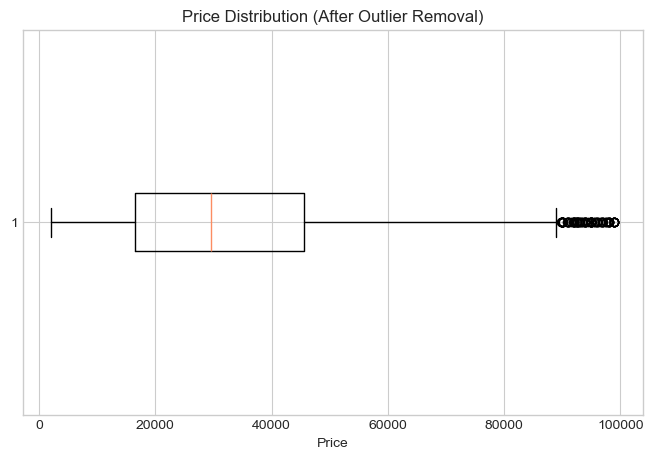

In [9]:
# ==========================================
# Outlier Detection and Removal using IQR
# ==========================================



# -------------------------------
# 1. Boxplot BEFORE removing outliers
# -------------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(df["price"], vert=False)
plt.title("Price Distribution (Before Outlier Removal)")
plt.xlabel("Price")
plt.show()

# -------------------------------
# 2. Calculate Q1, Q3 and IQR
# -------------------------------
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

# -------------------------------
# 3. Define lower and upper bounds
# -------------------------------
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# -------------------------------
# 4. Count outliers
# -------------------------------
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

print(f"Number of outliers: {outliers.shape[0]}")

# -------------------------------
# 5. Remove outliers
# -------------------------------
df_clean = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

print(f"Original shape : {df.shape}")
print(f"Cleaned shape  : {df_clean.shape}")

# -------------------------------
# 6. Boxplot AFTER removing outliers
# -------------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(df_clean["price"], vert=False)
plt.title("Price Distribution (After Outlier Removal)")
plt.xlabel("Price")
plt.show()

In [10]:
# ==========================================
# Features and Target
# ==========================================
X = df_clean.drop("price", axis=1)
y = df_clean["price"]
# ==========================================
# Train Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
# ==========================================
# Feature Scaling
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify Final Dataset
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(3012, 11)
(753, 11)
(3012,)
(753,)


In [11]:
# Part 3: Exploratory Data Analysis (EDA)

In [12]:
# ==========================================
# Summary Statistics
# ==========================================
df_clean.describe(include="all")

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000,3765.000000
mean,23.481009,940.764409,2015.269588,68075.092430,2.017264,576.503054,30.946082,157.830279,39.125631,0.740505,0.860823,33518.196547
std,16.447465,547.529522,6.096186,52086.969339,0.652771,299.884862,15.172704,112.658424,42.917523,0.438416,0.346177,21369.125682
min,0.000000,0.000000,1992.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2000.000000
25%,9.000000,500.000000,2012.000000,26600.000000,2.000000,329.000000,20.000000,34.000000,14.000000,0.000000,1.000000,16500.000000
50%,20.000000,922.000000,2017.000000,57237.000000,2.000000,582.000000,32.000000,128.000000,14.000000,1.000000,1.000000,29600.000000
75%,36.000000,1424.000000,2020.000000,97000.000000,2.000000,822.000000,38.000000,263.000000,71.000000,1.000000,1.000000,45500.000000
max,56.000000,1897.000000,2024.000000,405000.000000,6.000000,1145.000000,60.000000,318.000000,155.000000,1.000000,1.000000,99000.000000


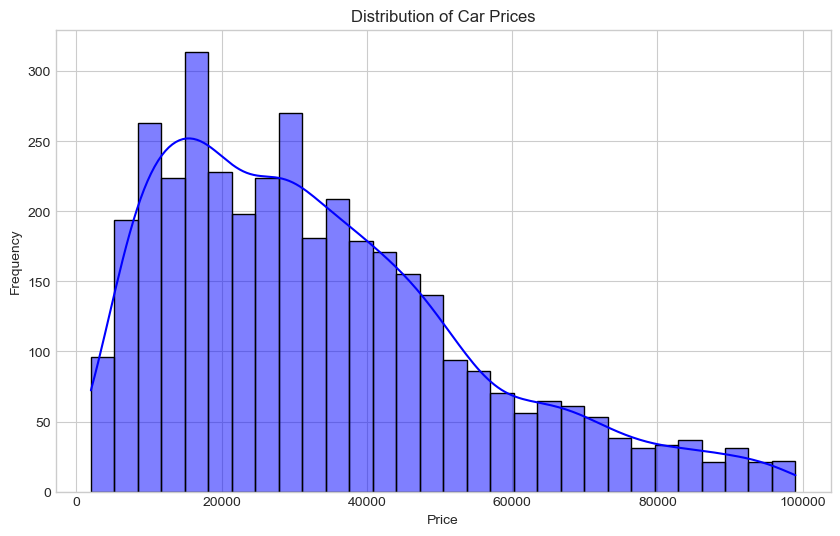

In [13]:
# ==========================================
# Step 2: Distribution of Target Variable (Price)
# ==========================================

plt.figure(figsize=(10,6))
sns.histplot(data=df_clean,x="price",bins=30,kde=True,color="blue")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

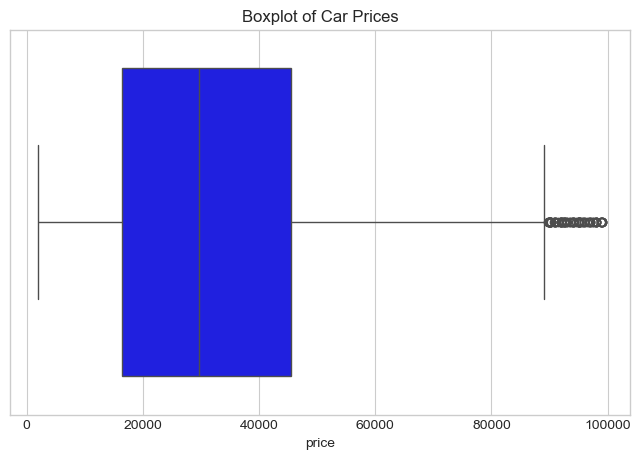

In [14]:
# ==========================================
# Step 3: Box plot
# ==========================================
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean["price"],color="blue")
plt.title("Boxplot of Car Prices")
plt.show()

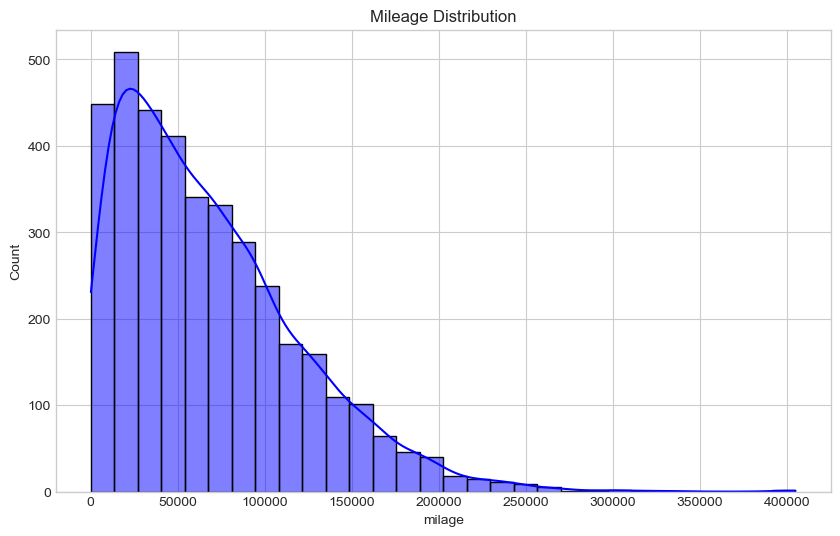

In [15]:
# ==========================================
# Step 4:Distribution of Mileage
# ==========================================
plt.figure(figsize=(10,6))
sns.histplot(data=df_clean,x="milage",bins=30,kde=True,color="blue")
plt.title("Mileage Distribution")
plt.show()

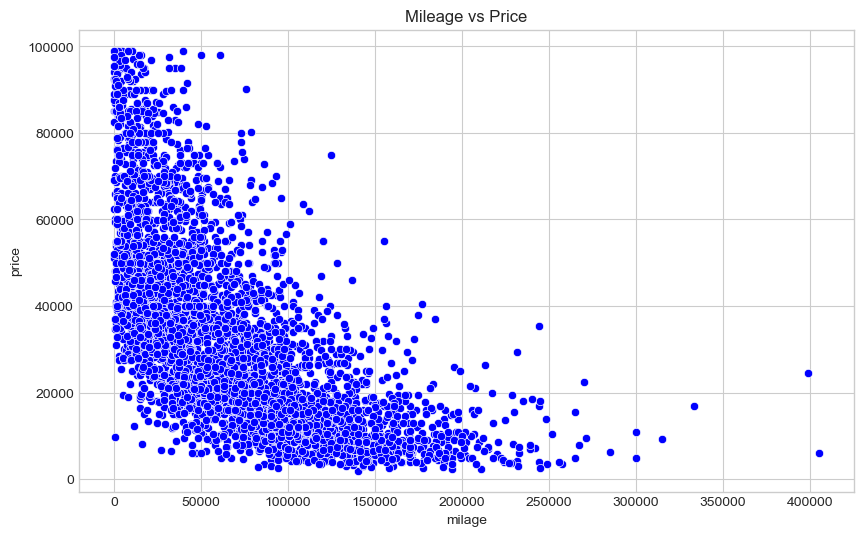

In [16]:
# ==========================================
# Step 5: Scatter Plot (Mileage vs Price)
# ==========================================

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean,x="milage",y="price",color="blue")
plt.title("Mileage vs Price")
plt.show()

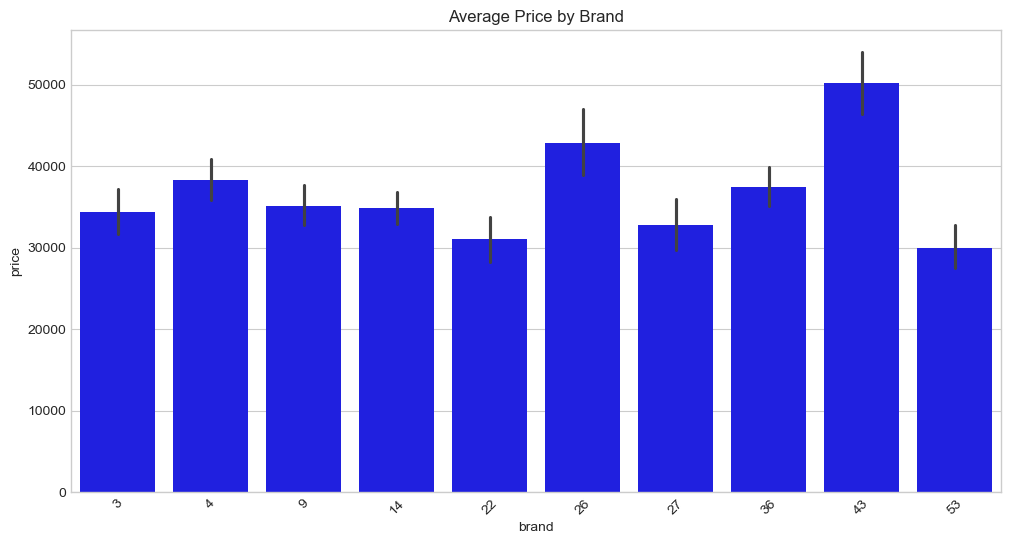

In [17]:
# ==========================================
# Step 6: Average Price by Brand
# ==========================================

top_brands = df_clean["brand"].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.barplot(data=df_clean[df_clean["brand"].isin(top_brands)],
            x="brand",y="price",color="blue",estimator="mean")
plt.xticks(rotation=45)
plt.title("Average Price by Brand")
plt.show()

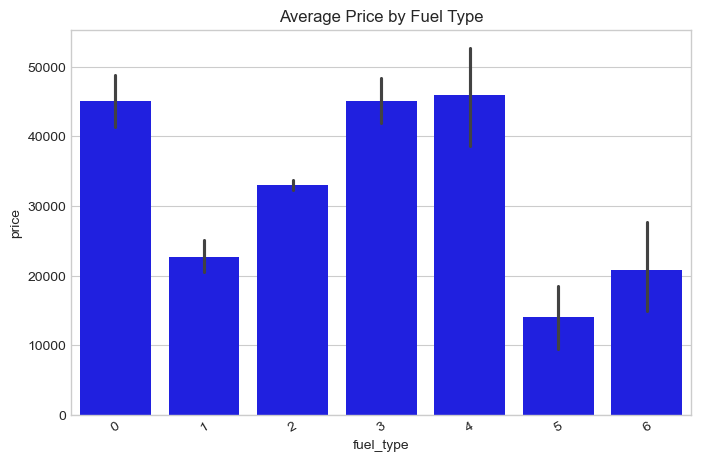

In [18]:
# ==========================================
# Step 7: Average Price by Fuel Type
# ==========================================

plt.figure(figsize=(8,5))
sns.barplot(data=df_clean,x="fuel_type",y="price",estimator="mean",color="blue")
plt.xticks(rotation=30)
plt.title("Average Price by Fuel Type")
plt.show()

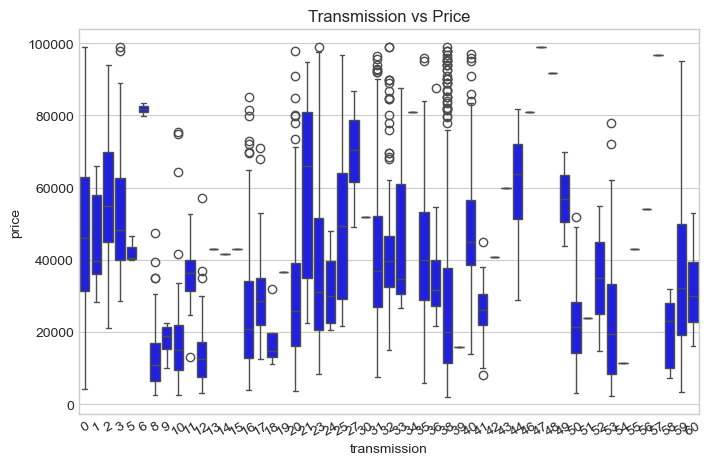

In [19]:
# ==========================================
# Step 8: Price by Transmission
# ==========================================

plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean,x="transmission",y="price",color="blue")
plt.xticks(rotation=30)
plt.title("Transmission vs Price")
plt.show()

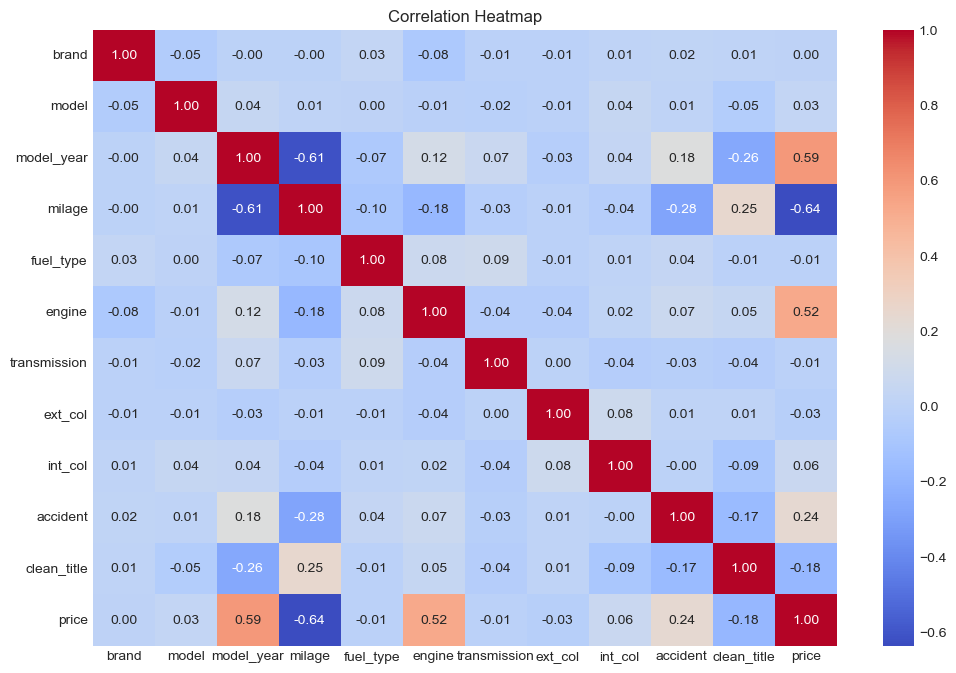

In [20]:
# ==========================================
# Step 9: Correlation Heatmap
# ==========================================

plt.figure(figsize=(12,8))
correlation = df_clean.corr(numeric_only=True)
sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

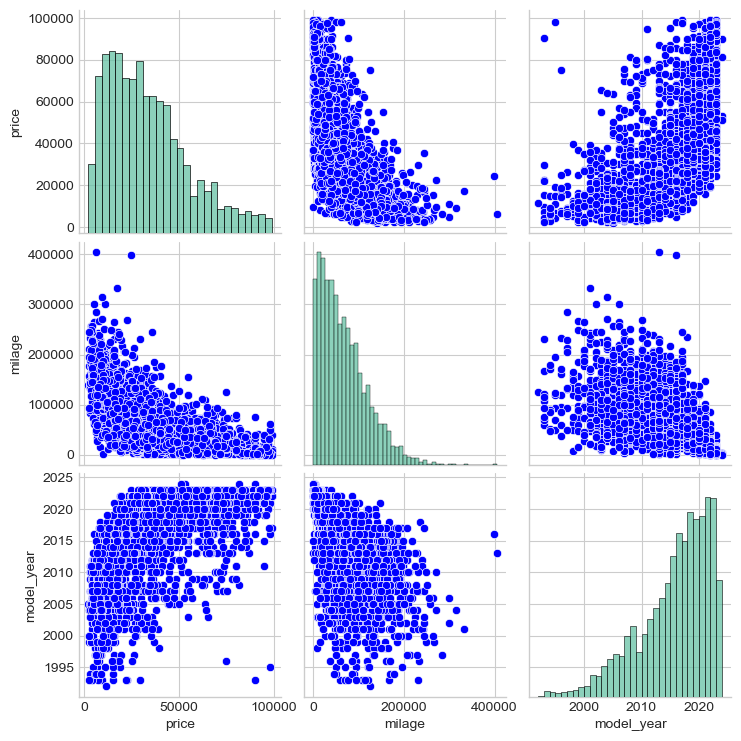

In [21]:
# ==========================================
# Step 10: Pair Plot
# ==========================================

selected_features = ["price", "milage", "model_year"]
sns.pairplot(df_clean[selected_features],plot_kws={"color": "blue"})
plt.show()

In [22]:
# Part 4: Regression Models
# ==========================================
# Step 1: Import Required Libraries
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.svm import SVR

# ==========================================
# Evaluation Metrics
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import time
print("Imported Successfully")

Imported Successfully


In [23]:
# ==========================================
# Step 2: Create Regression Models
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR()

}
print("Regression Model Created Successfully")

Regression Model Created Successfully


In [24]:
# ==========================================
# Step 3: Train Every Model
# ==========================================
results = []
for name, model in models.items():
    start_time = time.time()
    # Models that require scaling
    if name in [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Support Vector Regressor"
    ]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    # Tree-based models
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
    training_time = time.time() - start_time
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    results.append([name,training_time,mae,mse,rmse,r2])

In [25]:
# Step 4: Create Comparison Table
results_df = pd.DataFrame(results,columns=["Model","Training Time","MAE","MSE","RMSE","R2 Score"])
results_df

,Model,Training Time,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.043515,9952.428930,1.765357e+08,13286.674229,0.597242
1,Ridge Regression,0.004769,9952.068172,1.765259e+08,13286.304063,0.597265
2,Lasso Regression,0.004956,9952.350923,1.765324e+08,13286.549597,0.597250
3,Decision Tree,0.064204,8809.391766,1.851767e+08,13607.964180,0.577528
4,Random Forest,4.021874,6562.340159,9.593453e+07,9794.617145,0.781130
5,Gradient Boosting,1.019957,6599.932181,9.575724e+07,9785.562730,0.781534
6,Support Vector Regressor,1.701387,16519.405119,4.502859e+08,21219.941992,-0.027306


In [26]:
# Step 5: Sort Models
results_df = results_df.sort_values(by="R2 Score",ascending=False)
results_df

,Model,Training Time,MAE,MSE,RMSE,R2 Score
5,Gradient Boosting,1.019957,6599.932181,9.575724e+07,9785.562730,0.781534
4,Random Forest,4.021874,6562.340159,9.593453e+07,9794.617145,0.781130
1,Ridge Regression,0.004769,9952.068172,1.765259e+08,13286.304063,0.597265
2,Lasso Regression,0.004956,9952.350923,1.765324e+08,13286.549597,0.597250
0,Linear Regression,0.043515,9952.428930,1.765357e+08,13286.674229,0.597242
3,Decision Tree,0.064204,8809.391766,1.851767e+08,13607.964180,0.577528
6,Support Vector Regressor,1.701387,16519.405119,4.502859e+08,21219.941992,-0.027306


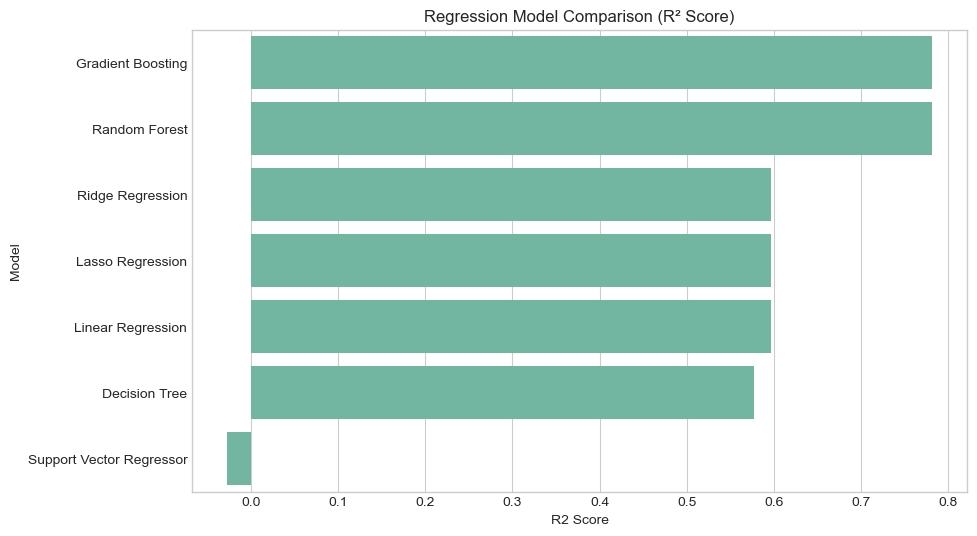

In [27]:
# ==========================================
# Step 6: Visualize Model Comparison (R² Score)
# ==========================================
plt.figure(figsize=(10,6))
sns.barplot(data=results_df,x="R2 Score",y="Model")
plt.title("Regression Model Comparison (R² Score)")
plt.show()

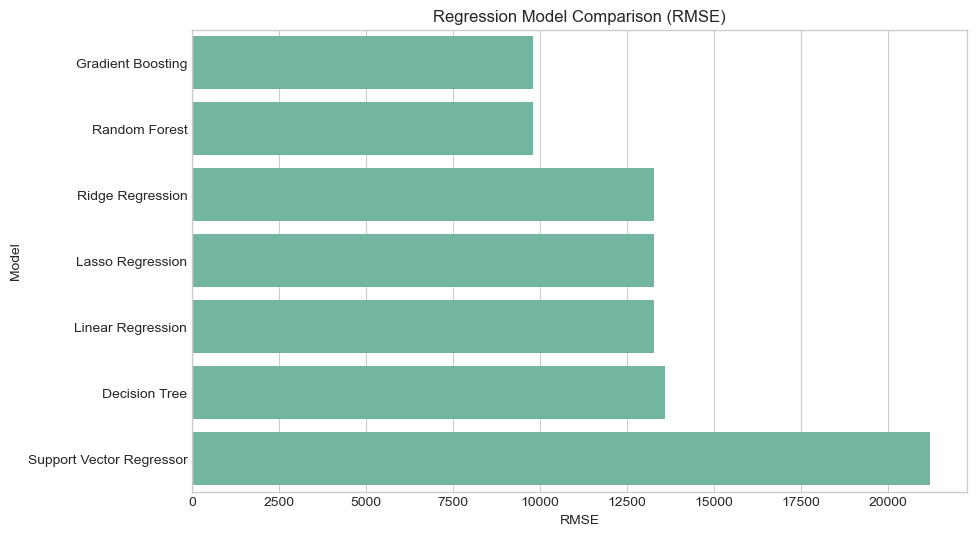

In [28]:
# ==========================================
# Step 7: Compare RMSE
# ==========================================
plt.figure(figsize=(10,6))
sns.barplot(data=results_df,x="RMSE",y="Model")
plt.title("Regression Model Comparison (RMSE)")
plt.show()

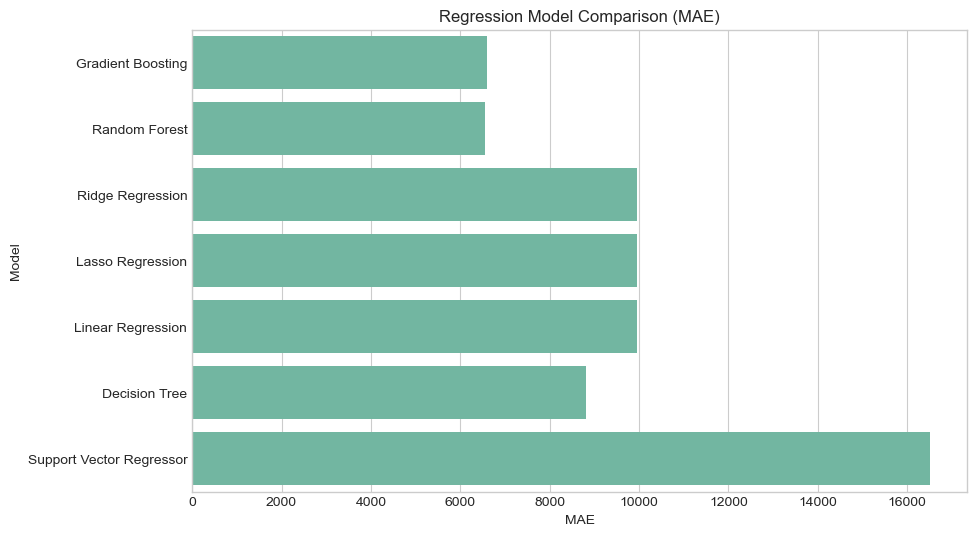

In [29]:
# ==========================================
# Step 8: Compare MAE
# ==========================================

plt.figure(figsize=(10,6))
sns.barplot(data=results_df,x="MAE",y="Model")
plt.title("Regression Model Comparison (MAE)")
plt.show()

In [30]:
# Part 5:Model Evaluation(Hyperparameter Tuning (Gradient Boosting Regressor))
# Step 1: Import Libraries
# ==========================================
# Hyperparameter Tuning
# ==========================================
from sklearn.model_selection import GridSearchCV

In [31]:
# ==========================================
# Base Gradient Boosting Model
# ==========================================

gb_model = GradientBoostingRegressor(
    random_state=42
)

In [32]:
# ==========================================
# Parameter Grid
# ==========================================
param_grid = {
    "n_estimators": [100, 200, 300],"learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],"min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],"subsample": [0.8, 1.0]

}

In [33]:
# ==========================================
# Grid Search
# ==========================================
grid_search = GridSearchCV(
    estimator=gb_model,param_grid=param_grid,
    scoring="r2",cv=5,n_jobs=-1,verbose=2)


In [ ]:
# ==========================================
# Train Grid Search
# ==========================================
grid_search.fit(X_train, y_train)
print("Grid search Train Sucessful")

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

In [ ]:
# ==========================================
# Best Model
# ==========================================
best_gb = grid_search.best_estimator_

In [ ]:
# ==========================================
# Prediction
# ==========================================
y_pred = best_gb.predict(X_test)

In [ ]:
# ==========================================
# Evaluation
# ==========================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)

In [ ]:
comparison = pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R² Score"],
    "Before Tuning":[6599.932181,9.575724e7,9785.562730,0.781534],
    "After Tuning":[mae,mse,rmse,r2]
})
comparison

In [ ]:
feature_importance = pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":best_gb.feature_importances_
})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance,x="Importance",y="Feature")
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
# 6. Regression Model Comparison

comparison_table = results_df.copy()
comparison_table

In [ ]:
# Visualization 1: R² Score

plt.figure(figsize=(10,6))
sns.barplot(data=results_df,x="R2 Score",y="Model")
plt.title("Comparison of Regression Models (R² Score)")
plt.show()

In [ ]:
# Visualization 2: RMSE
plt.figure(figsize=(10,6))
sns.barplot(data=results_df,x="RMSE",y="Model")
plt.title("Comparison of Regression Models (RMSE)")
plt.show()

In [ ]:
# Visualization 3: MAE
plt.figure(figsize=(10,6))
sns.barplot(data=results_df,x="MAE",y="Model")
plt.title("Comparison of Regression Models (MAE)")
plt.show()